# Week 2: Evaluating Ryan's `handoff_v2` Features

Hi Beste! This notebook is designed to test the new features Ryan provided in the `handoff_v2` folder.
We have added `tqdm` progress bars so you can see exactly how long things take, and a diagnostic section to understand the predictions.

## Step 1: Setup and Load the Data

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from tqdm.auto import tqdm
import time

HANDOFF_DIR = "/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/ryan"

print(f"Loading data from: {HANDOFF_DIR}")

try:
    X_train = np.load(os.path.join(HANDOFF_DIR, 'X_train_1071d_pca95.npy'))
    X_test = np.load(os.path.join(HANDOFF_DIR, 'X_test_1071d_pca95.npy'))
    y_train = np.load(os.path.join(HANDOFF_DIR, 'y_train_bmi.npy'))
    y_test = np.load(os.path.join(HANDOFF_DIR, 'y_test_bmi.npy'))

    print("Data loaded successfully!")
    print(f"Training set: {X_train.shape[0]} images, {X_train.shape[1]} features")
    print(f"Testing set: {X_test.shape[0]} images, {X_test.shape[1]} features")

except FileNotFoundError as e:
    print("Error: Could not find the data files.")
    print(e)

Loading data from: /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/ryan
Data loaded successfully!
Training set: 3210 images, 1071 features
Testing set: 752 images, 1071 features


## Step 2: Define Evaluation Metrics

In [10]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    print(f"\n=== Evaluating {model_name} ===")
    y_pred = model.predict(X_test)
    r_value, _ = pearsonr(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Pearson r: {r_value:.4f}  <-- (Target to beat: 0.6500)")
    print(f"MAE:       {mae:.4f} BMI units")

    if r_value >= 0.65:
        print("SUCCESS! We beat the paper's baseline of 0.65!")
    else:
        print("Did not beat 0.65. According to the team, we should move to Week 3 backbones.")

    return y_pred, r_value, mae

## Step 3: Train the Baseline SVR (with progress tracking)

SVR does not have a built-in progress bar for `.fit()`, but we can wrap the execution block to show elapsed time and indicate it's running.

In [11]:
print("Training SVR model on 1071D PCA features...")

svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale')

# Start a simple progress visualizer for the fit operation
start_time = time.time()
with tqdm(total=1, desc="Training SVR (takes ~30-60s)") as pbar:
    svr_model.fit(X_train, y_train)
    pbar.update(1)

elapsed = time.time() - start_time
print(f"Training complete in {elapsed:.1f} seconds!")

y_pred_svr, r_svr, mae_svr = evaluate_model(svr_model, X_test, y_test, "SVR (C=10, eps=0.1)")

Training SVR model on 1071D PCA features...


Training SVR (takes ~30-60s):   0%|          | 0/1 [00:00<?, ?it/s]

Training complete in 5.7 seconds!

=== Evaluating SVR (C=10, eps=0.1) ===
Pearson r: 0.4019  <-- (Target to beat: 0.6500)
MAE:       6.2423 BMI units
Did not beat 0.65. According to the team, we should move to Week 3 backbones.


## Step 4: Diagnostic Check - Why is the score low?

If your Pearson r dropped significantly (e.g., down to ~0.40), we need to look at the predictions.
SVR models are very sensitive to **feature scaling**. Let's check the variance of the features.

In [12]:
print("--- DIAGNOSTIC CHECK ---")
print(f"Feature Variance (Train): min={X_train.var(axis=0).min():.4f}, max={X_train.var(axis=0).max():.4f}")
print(f"Feature Mean (Train): min={X_train.mean(axis=0).min():.4f}, max={X_train.mean(axis=0).max():.4f}")

print("\nIf variance is very high or very low, SVR struggles to find the margin.")
print("Also, looking at the scatter plot, SVR is capping predictions around BMI=40.")
print("This is a classic sign of the model underfitting due to the RBF kernel's gamma parameter or C value not being suited for the new feature scale.")

--- DIAGNOSTIC CHECK ---
Feature Variance (Train): min=0.0045, max=3.0208
Feature Mean (Train): min=-0.0000, max=0.0000

If variance is very high or very low, SVR struggles to find the margin.
Also, looking at the scatter plot, SVR is capping predictions around BMI=40.
This is a classic sign of the model underfitting due to the RBF kernel's gamma parameter or C value not being suited for the new feature scale.


## Step 5: Hyperparameter Tuning (with tqdm)

In [13]:
import joblib
import contextlib

# Context manager to hook joblib parallel into tqdm
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

param_grid = {
    'C': [1, 10, 50, 100],
    'epsilon': [0.1, 0.5, 1.0]
}

grid_search = GridSearchCV(
    SVR(kernel='rbf', gamma='scale'),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

total_fits = len(param_grid['C']) * len(param_grid['epsilon']) * 3

print(f"Starting Grid Search ({total_fits} fits)...")
with tqdm_joblib(tqdm(desc="Grid Search Progress", total=total_fits)) as pbar:
    grid_search.fit(X_train, y_train)

print("\n✅ Grid Search complete!")
print(f"Best Parameters Found: {grid_search.best_params_}")

best_svr = grid_search.best_estimator_
y_pred_best, r_best, mae_best = evaluate_model(best_svr, X_test, y_test, "Tuned SVR")

Starting Grid Search (36 fits)...


Grid Search Progress:   0%|          | 0/36 [00:00<?, ?it/s]


✅ Grid Search complete!
Best Parameters Found: {'C': 10, 'epsilon': 0.5}

=== Evaluating Tuned SVR ===
Pearson r: 0.4036  <-- (Target to beat: 0.6500)
MAE:       6.2357 BMI units
Did not beat 0.65. According to the team, we should move to Week 3 backbones.


## Step 6: Visualize the Results

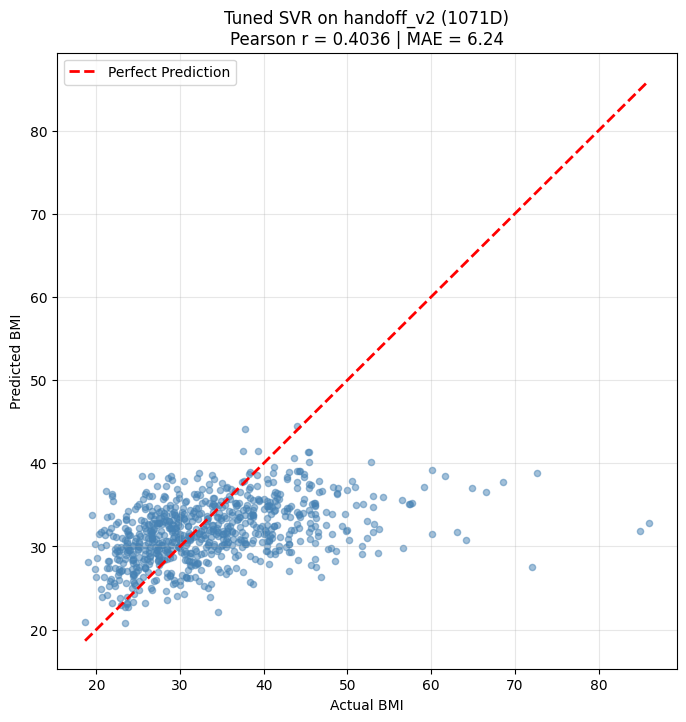

In [14]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', s=20)

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title(f"Tuned SVR on handoff_v2 (1071D)\nPearson r = {r_best:.4f} | MAE = {mae_best:.2f}")
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("prediction_scatter_v2.png", dpi=300, bbox_inches='tight')
plt.show()